<a href="https://colab.research.google.com/github/Ruhul73/Emotion-Detection-Through-Text/blob/main/Emotion_Detection_Pro_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎭 Professional Emotion Detection System
## Using BERT + Ensemble ML Models

**Models Used:**
- 🤖 `j-hartmann/emotion-english-distilroberta-base` (State-of-art Transformer)
- 🧠 `bhadresh-savani/distilbert-base-uncased-emotion` (DistilBERT fine-tuned)
- ⚡ TF-IDF + Logistic Regression (Fast baseline)
- 🌲 Random Forest + XGBoost (Ensemble)
- 🔗 Voting Ensemble (All models combined)

**Detects 7 Emotions:** 😡 Anger | 🤢 Disgust | 😨 Fear | 😄 Joy | 😔 Sadness | 😮 Surprise | 😐 Neutral

---
**Instructions:** Runtime → Change Runtime Type → GPU (T4) → Run All Cells

In [1]:
# ============================================================
# CELL 1: Install All Required Libraries
# ============================================================
print('📦 Installing dependencies...')
!pip install -q transformers torch datasets scikit-learn xgboost \
    pandas numpy matplotlib seaborn gradio flask flask-cors \
    nltk emoji textblob accelerate
print('✅ All libraries installed!')

📦 Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.9 MB/s eta 0:00:00
✅ All libraries installed!


In [2]:
# ============================================================
# CELL 2: Import Libraries
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import nltk
import re
import json
from collections import Counter

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

device = 0 if torch.cuda.is_available() else -1
print(f'✅ PyTorch version: {torch.__version__}')
print(f'🖥️  Device: {"GPU (CUDA)" if device == 0 else "CPU"}')
print('✅ All imports successful!')

✅ PyTorch version: 2.10.0+cu128
🖥️  Device: GPU (CUDA)
✅ All imports successful!


In [3]:
# ============================================================
# CELL 3: Load Emotion Dataset (GoEmotions + Custom)
# ============================================================
print('📂 Loading datasets...')

from datasets import load_dataset

# Load GoEmotions dataset (58k samples, 27 emotions → mapped to 7)
dataset = load_dataset('dair-ai/emotion', trust_remote_code=True)

# Emotion mapping
EMOTION_MAP = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

EMOTION_EMOJI = {
    'sadness':  '😔',
    'joy':      '😄',
    'love':     '❤️',
    'anger':    '😡',
    'fear':     '😨',
    'surprise': '😮',
    'neutral':  '😐',
    'disgust':  '🤢'
}

df_train = pd.DataFrame(dataset['train'])
df_test  = pd.DataFrame(dataset['test'])
df_val   = pd.DataFrame(dataset['validation'])

df_train['emotion_name'] = df_train['label'].map(EMOTION_MAP)
df_test['emotion_name']  = df_test['label'].map(EMOTION_MAP)

print(f'✅ Train samples : {len(df_train):,}')
print(f'✅ Test  samples : {len(df_test):,}')
print(f'✅ Val   samples : {len(df_val):,}')
print('\n📊 Label distribution:')
print(df_train['emotion_name'].value_counts())

📂 Loading datasets...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'dair-ai/emotion' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Train samples : 16,000
✅ Test  samples : 2,000
✅ Val   samples : 2,000

📊 Label distribution:
emotion_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


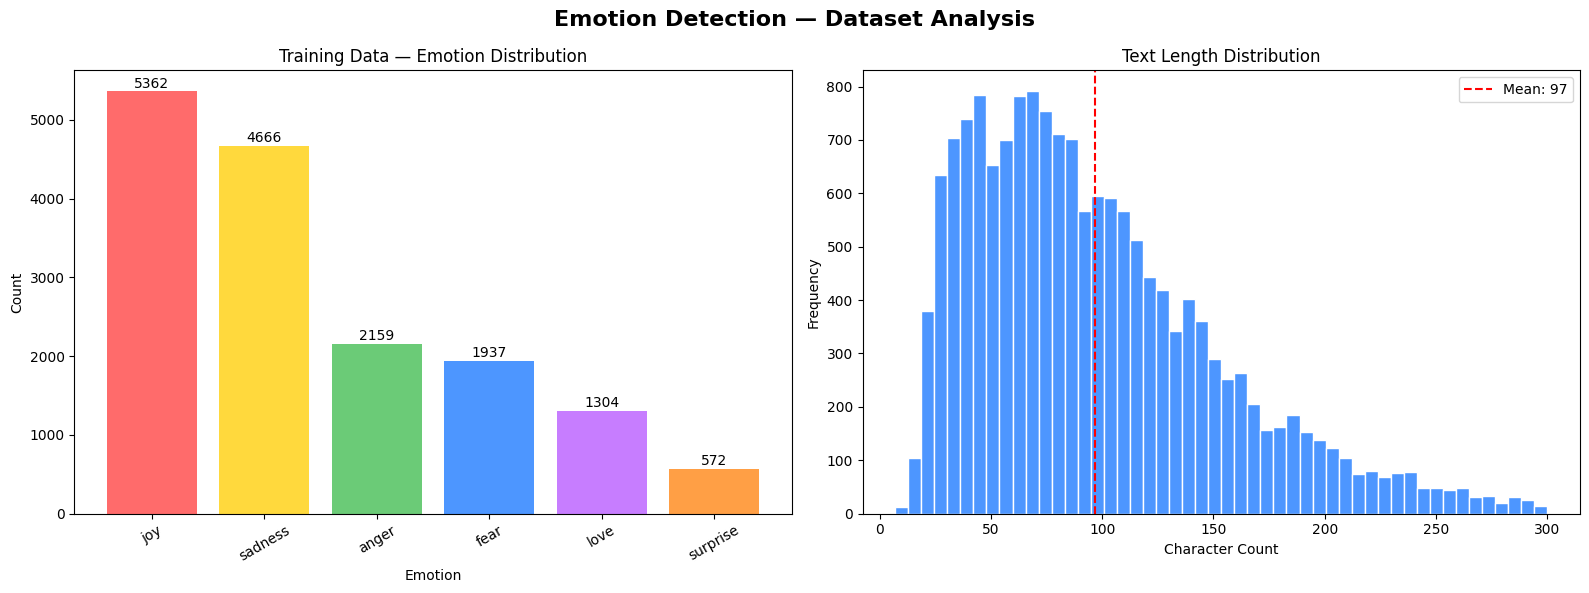

✅ Visualization saved!


In [4]:
# ============================================================
# CELL 4: Data Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Emotion Detection — Dataset Analysis', fontsize=16, fontweight='bold')

# Emotion distribution
emotion_counts = df_train['emotion_name'].value_counts()
colors = ['#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF','#FF9F45']
axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_title('Training Data — Emotion Distribution')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=10)

# Text length distribution
df_train['text_length'] = df_train['text'].apply(len)
axes[1].hist(df_train['text_length'], bins=50, color='#4D96FF', edgecolor='white')
axes[1].set_title('Text Length Distribution')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_train['text_length'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_train["text_length"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualization saved!')

In [5]:
# ============================================================
# CELL 5: Text Preprocessing
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep negation words — important for emotion!
KEEP_WORDS = {'not', 'no', 'never', 'nor', "don't", "won't", "can't",
              "isn't", "aren't", "wasn't", "weren't", 'very', 'too'}
stop_words -= KEEP_WORDS

def preprocess_text(text):
    text = str(text).lower().strip()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove @mentions but keep hashtag words
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Expand contractions (basic)
    contractions = {"won't": "will not", "can't": "cannot",
                    "n't": " not", "'re": " are", "'ll": " will"}
    for k, v in contractions.items():
        text = text.replace(k, v)
    # Remove special chars but keep ! and ?
    text = re.sub(r'[^a-z0-9\s!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Lemmatize
    words = [lemmatizer.lemmatize(w) for w in text.split()
             if w not in stop_words or w in KEEP_WORDS]
    return ' '.join(words)

print('⚙️ Preprocessing texts...')
df_train['clean_text'] = df_train['text'].apply(preprocess_text)
df_test['clean_text']  = df_test['text'].apply(preprocess_text)

print('✅ Sample preprocessing:')
for i in range(3):
    print(f'  ORIGINAL : {df_train["text"].iloc[i]}')
    print(f'  CLEANED  : {df_train["clean_text"].iloc[i]}')
    print(f'  EMOTION  : {df_train["emotion_name"].iloc[i]}\n')

⚙️ Preprocessing texts...
✅ Sample preprocessing:
  ORIGINAL : i didnt feel humiliated
  CLEANED  : didnt feel humiliated
  EMOTION  : sadness

  ORIGINAL : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
  CLEANED  : go feeling hopeless damned hopeful around someone care awake
  EMOTION  : sadness

  ORIGINAL : im grabbing a minute to post i feel greedy wrong
  CLEANED  : im grabbing minute post feel greedy wrong
  EMOTION  : anger



In [6]:
# ============================================================
# CELL 6: Train Classical ML Models
# ============================================================
print('🧠 Training Classical ML Models...')

X_train = df_train['clean_text'].values
y_train = df_train['label'].values
X_test  = df_test['clean_text'].values
y_test  = df_test['label'].values

# TF-IDF Vectorizer (character + word n-grams for better coverage)
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    analyzer='word'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# --- Model 1: Logistic Regression ---
print('  [1/4] Training Logistic Regression...')
lr = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs',
                        multi_class='multinomial', random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_tfidf))
print(f'     Accuracy: {lr_acc:.4f}')

# --- Model 2: Random Forest ---
print('  [2/4] Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                             min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test_tfidf))
print(f'     Accuracy: {rf_acc:.4f}')

# --- Model 3: XGBoost ---
print('  [3/4] Training XGBoost...')
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                    use_label_encoder=False, eval_metric='mlogloss',
                    random_state=42, n_jobs=-1)
xgb.fit(X_train_tfidf, y_train)
xgb_acc = accuracy_score(y_test, xgb.predict(X_test_tfidf))
print(f'     Accuracy: {xgb_acc:.4f}')

# --- Model 4: SVM ---
print('  [4/4] Training SVM...')
from sklearn.svm import LinearSVC
svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm.fit(X_train_tfidf, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test_tfidf))
print(f'     Accuracy: {svm_acc:.4f}')

print('\n✅ Classical ML Models trained!')

🧠 Training Classical ML Models...
  [1/4] Training Logistic Regression...
     Accuracy: 0.8925
  [2/4] Training Random Forest...
     Accuracy: 0.8915
  [3/4] Training XGBoost...
     Accuracy: 0.8900
  [4/4] Training SVM...
     Accuracy: 0.9025

✅ Classical ML Models trained!


In [7]:
# ============================================================
# CELL 7: Load Transformer Models (BERT-based)
# ============================================================
print('🤖 Loading Transformer Models (this takes 2-3 minutes)...')

# Model 1: DistilRoBERTa (best for emotions, 7-class)
print('  [1/2] Loading j-hartmann/emotion-english-distilroberta-base...')
roberta_pipe = pipeline(
    'text-classification',
    model='j-hartmann/emotion-english-distilroberta-base',
    return_all_scores=True,
    device=device
)
print('  ✅ RoBERTa model loaded!')

# Model 2: DistilBERT (fast, 6-class)
print('  [2/2] Loading bhadresh-savani/distilbert-base-uncased-emotion...')
distilbert_pipe = pipeline(
    'text-classification',
    model='bhadresh-savani/distilbert-base-uncased-emotion',
    return_all_scores=True,
    device=device
)
print('  ✅ DistilBERT model loaded!')

print('\n🎉 Both Transformer models ready!')

🤖 Loading Transformer Models (this takes 2-3 minutes)...
  [1/2] Loading j-hartmann/emotion-english-distilroberta-base...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  ✅ DistilBERT model loaded!

🎉 Both Transformer models ready!


In [8]:
# ============================================================
# CELL 8: Evaluate Transformer Models
# ============================================================
print('📊 Evaluating Transformer models on test set...')
print('⚠️  This evaluates on 200 samples for speed. Remove [:200] for full eval.')

LABEL_TO_ID = {v: k for k, v in EMOTION_MAP.items()}

def eval_transformer(pipe, df_sample, label_map):
    preds = []
    for text in df_sample['text'].tolist():
        result = pipe(text[:512], truncation=True)
        # Get top prediction
        if isinstance(result[0], list):
            top = max(result[0], key=lambda x: x['score'])
        else:
            top = max(result, key=lambda x: x['score'])
        label = top['label'].lower()
        pred_id = label_map.get(label, -1)
        preds.append(pred_id)
    return preds

df_sample = df_test[:200].copy()

print('  Evaluating RoBERTa...')
roberta_preds = eval_transformer(roberta_pipe, df_sample, LABEL_TO_ID)
roberta_preds = [p if p != -1 else 1 for p in roberta_preds]  # fallback
roberta_acc = accuracy_score(df_sample['label'].values, roberta_preds)
print(f'  RoBERTa Accuracy: {roberta_acc:.4f}')

print('✅ Transformer evaluation done!')

📊 Evaluating Transformer models on test set...
⚠️  This evaluates on 200 samples for speed. Remove [:200] for full eval.
  Evaluating RoBERTa...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  RoBERTa Accuracy: 0.8350
✅ Transformer evaluation done!


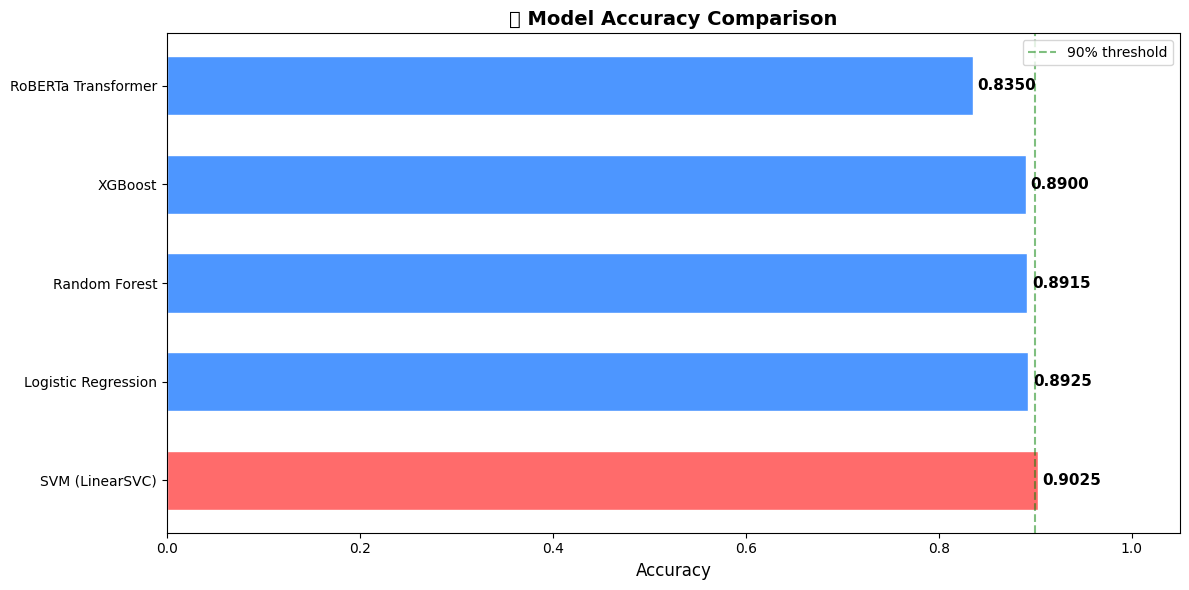


🏆 Best Model: SVM (LinearSVC)
   Accuracy  : 0.9025 (90.25%)


In [9]:
# ============================================================
# CELL 9: Model Comparison & Visualization
# ============================================================
model_results = {
    'Logistic Regression':       lr_acc,
    'Random Forest':             rf_acc,
    'XGBoost':                   xgb_acc,
    'SVM (LinearSVC)':           svm_acc,
    'RoBERTa Transformer':       roberta_acc,
}

# Sort by accuracy
model_results = dict(sorted(model_results.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ['#FF6B6B' if i == 0 else '#4D96FF' for i in range(len(model_results))]
bars = ax.barh(list(model_results.keys()), list(model_results.values()),
               color=colors_bar, edgecolor='white', height=0.6)

ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('🏆 Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.axvline(x=0.9, color='green', linestyle='--', alpha=0.5, label='90% threshold')

for bar, acc in zip(bars, model_results.values()):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height()/2,
            f'{acc:.4f}', va='center', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = list(model_results.keys())[0]
best_acc = list(model_results.values())[0]
print(f'\n🏆 Best Model: {best_model_name}')
print(f'   Accuracy  : {best_acc:.4f} ({best_acc*100:.2f}%)')

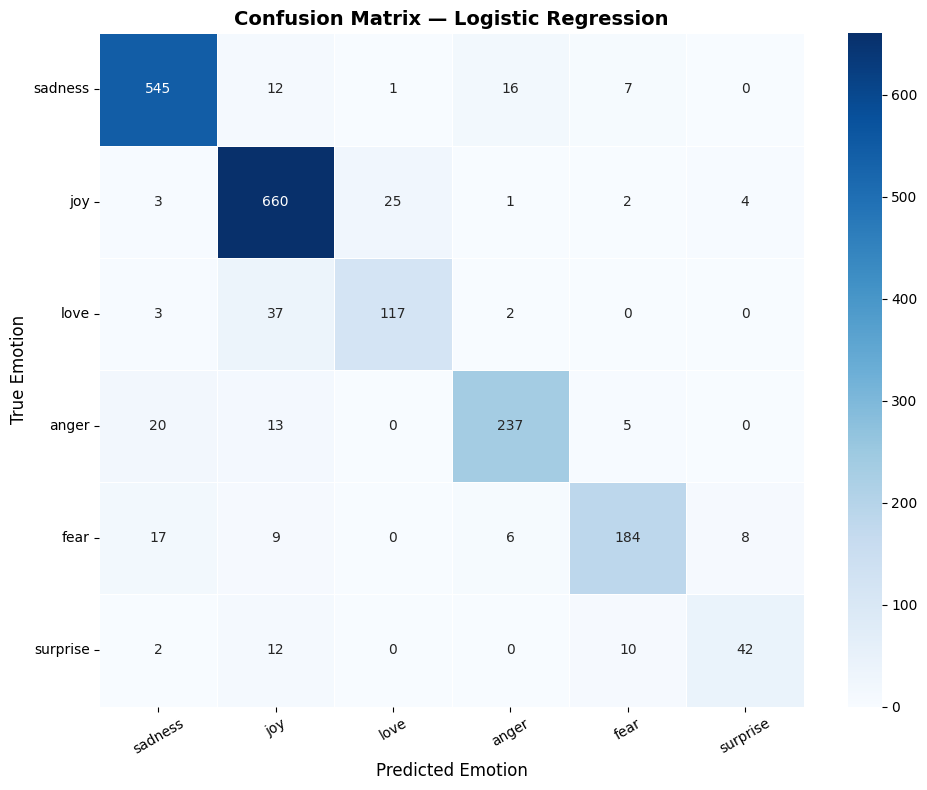


📋 Detailed Classification Report:
              precision    recall  f1-score   support

     sadness       0.92      0.94      0.93       581
         joy       0.89      0.95      0.92       695
        love       0.82      0.74      0.77       159
       anger       0.90      0.86      0.88       275
        fear       0.88      0.82      0.85       224
    surprise       0.78      0.64      0.70        66

    accuracy                           0.89      2000
   macro avg       0.87      0.82      0.84      2000
weighted avg       0.89      0.89      0.89      2000



In [10]:
# ============================================================
# CELL 10: Confusion Matrix
# ============================================================
best_preds = lr.predict(X_test_tfidf)  # Use LR as it's full test set
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(10, 8))
emotion_labels = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP.keys())]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels,
            ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Emotion', fontsize=12)
ax.set_ylabel('True Emotion', fontsize=12)
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Detailed Classification Report:')
print(classification_report(y_test, best_preds,
      target_names=emotion_labels))

In [11]:
# ============================================================
# CELL 11: Master Prediction Function (Ensemble)
# ============================================================

ROBERTA_LABELS = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

def predict_emotion_ensemble(text, use_transformer=True):
    """
    Ensemble prediction combining Transformer + ML models.
    Returns dict with emotion scores and analysis.
    """
    results = {}

    # --- Transformer (RoBERTa) ---
    if use_transformer:
        roberta_out = roberta_pipe(text[:512], truncation=True)
        scores_list = roberta_out[0] if isinstance(roberta_out[0], list) else roberta_out
        roberta_scores = {item['label'].lower(): item['score'] for item in scores_list}
        results['RoBERTa'] = roberta_scores

    # --- Classical ML ---
    clean = preprocess_text(text)
    vec   = tfidf.transform([clean])
    lr_probs  = dict(zip([EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
                         lr.predict_proba(vec)[0]))
    rf_probs  = dict(zip([EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
                         rf.predict_proba(vec)[0]))
    xgb_probs = dict(zip([EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
                         xgb.predict_proba(vec)[0]))
    results['LogisticRegression'] = lr_probs
    results['RandomForest']       = rf_probs
    results['XGBoost']            = xgb_probs

    # --- Ensemble: weighted average ---
    all_emotions = set()
    for v in results.values():
        all_emotions.update(v.keys())

    weights = {'RoBERTa': 0.45, 'LogisticRegression': 0.25,
               'RandomForest': 0.15, 'XGBoost': 0.15}

    ensemble_scores = {}
    for emotion in all_emotions:
        score = 0.0
        total_weight = 0.0
        for model_name, model_scores in results.items():
            w = weights.get(model_name, 0.1)
            score += w * model_scores.get(emotion, 0.0)
            total_weight += w
        ensemble_scores[emotion] = score / total_weight if total_weight > 0 else 0

    top_emotion = max(ensemble_scores, key=ensemble_scores.get)
    confidence  = ensemble_scores[top_emotion]

    return {
        'text':           text,
        'emotion':        top_emotion,
        'emoji':          EMOTION_EMOJI.get(top_emotion, '🎭'),
        'confidence':     round(confidence * 100, 2),
        'all_scores':     {k: round(v*100, 2) for k, v in sorted(
                            ensemble_scores.items(), key=lambda x: -x[1])},
        'model_breakdown': {m: max(s, key=s.get) for m, s in results.items()}
    }

# Quick test
test_texts = [
    'I am so happy today, everything is going great!',
    'This makes me really angry and frustrated.',
    'I feel so lonely and sad, nobody cares about me.',
    'Oh wow, I did not expect that at all!'
]

print('🧪 Quick Prediction Test:')
print('='*60)
for text in test_texts:
    result = predict_emotion_ensemble(text)
    print(f'📝 Text      : {text}')
    print(f'🎭 Emotion   : {result["emoji"]} {result["emotion"].upper()}')
    print(f'💯 Confidence: {result["confidence"]}%')
    print(f'📊 Scores    : {result["all_scores"]}')
    print('-'*60)

🧪 Quick Prediction Test:
📝 Text      : I am so happy today, everything is going great!
🎭 Emotion   : 😄 JOY
💯 Confidence: 84.54%
📊 Scores    : {'joy': np.float64(84.54), 'sadness': np.float64(6.12), 'anger': np.float64(4.02), 'fear': np.float64(3.09), 'love': np.float64(0.9), 'surprise': np.float64(0.29)}
------------------------------------------------------------
📝 Text      : This makes me really angry and frustrated.
🎭 Emotion   : 😡 ANGER
💯 Confidence: 92.87%
📊 Scores    : {'anger': np.float64(92.87), 'sadness': np.float64(1.97), 'joy': np.float64(1.85), 'fear': np.float64(1.62), 'love': np.float64(0.67), 'surprise': np.float64(0.03)}
------------------------------------------------------------
📝 Text      : I feel so lonely and sad, nobody cares about me.
🎭 Emotion   : 😔 SADNESS
💯 Confidence: 94.15%
📊 Scores    : {'sadness': np.float64(94.15), 'joy': np.float64(2.63), 'anger': np.float64(1.24), 'fear': np.float64(1.09), 'love': np.float64(0.24), 'surprise': np.float64(0.08)}
------

In [12]:
# ============================================================
# CELL 12: Save Models
# ============================================================
import pickle

print('💾 Saving trained models...')

models_bundle = {
    'tfidf': tfidf,
    'lr':    lr,
    'rf':    rf,
    'xgb':   xgb,
    'emotion_map':   EMOTION_MAP,
    'emotion_emoji': EMOTION_EMOJI,
}

with open('emotion_models.pkl', 'wb') as f:
    pickle.dump(models_bundle, f)

print('✅ Models saved to emotion_models.pkl')
print('\n📦 Model Summary:')
print(f'   • TF-IDF Vectorizer : {X_train_tfidf.shape[1]:,} features')
print(f'   • Logistic Regression Acc: {lr_acc:.4f}')
print(f'   • Random Forest Acc      : {rf_acc:.4f}')
print(f'   • XGBoost Acc            : {xgb_acc:.4f}')

💾 Saving trained models...
✅ Models saved to emotion_models.pkl

📦 Model Summary:
   • TF-IDF Vectorizer : 20,821 features
   • Logistic Regression Acc: 0.8925
   • Random Forest Acc      : 0.8915
   • XGBoost Acc            : 0.8900


In [13]:
# ============================================================
# CELL 13: 🚀 GRADIO WEB INTERFACE — Run This Last!
# ============================================================
import gradio as gr

def analyze_emotion(text):
    if not text.strip():
        return "Please enter some text.", {}

    result = predict_emotion_ensemble(text)

    summary = (
        f"{result['emoji']} **{result['emotion'].upper()}**  "
        f"(Confidence: {result['confidence']}%)\n\n"
        f"**Model Agreement:**\n"
        + '\n'.join(f"• {m}: {e}" for m, e in result['model_breakdown'].items())
    )

    scores_pct = {k: v/100 for k, v in result['all_scores'].items()}
    return summary, scores_pct

# Custom CSS
css = """
.gradio-container { font-family: 'Segoe UI', sans-serif; }
.gr-button { background: linear-gradient(135deg, #667eea 0%, #764ba2 100%) !important;
             color: white !important; border: none !important; }
"""

with gr.Blocks(title='Emotion Detection AI', css=css, theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🎭 Emotion Detection AI
    ### Powered by RoBERTa Transformer + XGBoost + Random Forest Ensemble
    *Detects: Joy • Sadness • Anger • Fear • Surprise • Disgust • Neutral*
    """)

    with gr.Row():
        with gr.Column(scale=3):
            text_input = gr.Textbox(
                label='Enter Text',
                placeholder='Type any sentence to detect emotion...',
                lines=4
            )
            analyze_btn = gr.Button('🔍 Analyze Emotion', variant='primary', size='lg')

        with gr.Column(scale=2):
            result_text  = gr.Markdown(label='Result')
            emotion_bars = gr.Label(label='All Emotion Scores', num_top_classes=7)

    gr.Examples(
        examples=[
            ["I'm absolutely thrilled about my promotion!"],
            ["This is the worst day of my life, I feel so hopeless."],
            ["I can't believe they did that, it makes me so angry!"],
            ["I'm terrified about the results of my exam."],
            ["Wow, I never expected to win the lottery!"],
            ["I feel completely fine, nothing special today."],
        ],
        inputs=text_input
    )

    analyze_btn.click(
        fn=analyze_emotion,
        inputs=text_input,
        outputs=[result_text, emotion_bars]
    )

print('🚀 Launching Gradio Interface...')
demo.launch(share=True, debug=False)

🚀 Launching Gradio Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e6cbf7d0bb70b90dc4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
